# 初期設定・関数

tarアーカイブでダウンロードした場合，解凍する作業が必要．

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from astropy.io import fits
from astropy.time import Time
from tqdm import tqdm
import re
import io
import imageio.v2 as imageio
import sunpy.map
import gc
import astropy.units as u

# --- 出力フォルダと関数の定義（変更なし） ---

data_folder = r'D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits'
output_folder = r'D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\output'
fts_files = sorted(glob.glob(os.path.join(data_folder, "*.fts")))
os.makedirs(output_folder, exist_ok=True)

def read_fits_file(fits_path: str):
    """FITSファイルを読み込み、データとヘッダーを返す."""
    with fits.open(fits_path, ignore_missing_end=True) as hdul:
        data = hdul[0].data
        header = hdul[0].header
    return data, header

def calculate_statistics(data, exclude_zeros=False):
    """データの統計情報を計算."""
    if exclude_zeros:
        data = data[data > 0]
    if data.size == 0:
        return {"min": 0, "max": 0, "mean": 0, "median": 0, "std": 0}
    return {
        "min": np.min(data),
        "max": np.max(data),
        "mean": np.mean(data),
        "median": np.median(data),
        "std": np.std(data),
    }

def draw_frame(data, header, ax):
    """単一フレームを描画する関数（変更なし）."""
    solar_x = header.get('CRPIX1', data.shape[1] // 2) - 1
    solar_y = header.get('CRPIX2', data.shape[0] // 2) - 1
    solar_radius = header.get('R_SUN', 0)

    pixel_to_rsun = 1 / solar_radius if solar_radius > 0 else 1

    stats = calculate_statistics(data)
    data_mean, data_std = stats["mean"], stats["std"]
    custom_vmin = -1.0
    custom_vmax = 4

    extent = [
        -solar_x * pixel_to_rsun, (data.shape[1] - solar_x) * pixel_to_rsun,
        -solar_y * pixel_to_rsun, (data.shape[0] - solar_y) * pixel_to_rsun
    ]
    ax.clear()
    im = ax.imshow(data, cmap='gray', origin='lower', vmin=custom_vmin, vmax=custom_vmax, extent=extent)

    ax.scatter(0, 0, color='red', s=50, label="Solar Center")
    if solar_radius > 0:
        circle = Circle((0, 0), 1, color='red', fill=False, lw=1.5, label="Solar Disk")
        ax.add_patch(circle)
        
    # こちらの円は不要であればコメントアウトしてください
    custom_radius = np.sqrt((0 - solar_x) ** 2 + (solar_y - solar_y) ** 2) * pixel_to_rsun
    circle = Circle((0, 0), custom_radius, color='white', fill=False, linestyle='--', lw=1.0, label="Custom Radius")
    ax.add_patch(circle)

    ax.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.5)

    date_obs = header.get('DATE-OBS', 'Unknown Time')
    ax.set_title(f"kcor_ngrf: {date_obs}", fontsize=12)
    ax.set_xlabel("X [Solar Radius $R_\\odot$]", fontsize=10)
    ax.set_ylabel("Y [Solar Radius $R_\\odot$]", fontsize=10)

    return im

# --- ★★★ 動画作成関数（修正箇所） ★★★ ---
def create_movie_from_fits_imageio(start_time_str: str, end_time_str: str, data_folder: str, output_path: str, fps: int = 15):

    print("動画の作成を開始します...")
    
    # 1. 時刻オブジェクトの準備 (変更なし)
    try:
        start_time = Time(start_time_str, scale='utc')
        end_time = Time(end_time_str, scale='utc')
        print(f"対象期間: {start_time.iso} から {end_time.iso} まで")
    except Exception as e:
        print(f"時刻の変換に失敗しました: {e}")
        return

    # 2. 対象ファイルのフィルタリング (変更なし)
    all_files = sorted(glob.glob(os.path.join(data_folder, "*.fts")))
    files_to_process = []
    pattern = re.compile(r'(\d{8})_(\d{6})')
    
    for f_path in all_files:
        match = pattern.search(os.path.basename(f_path))
        if match:
            date_str, time_str = match.groups()
            try:
                iso_time_str = f"{date_str[0:4]}-{date_str[4:6]}-{date_str[6:8]} {time_str[0:2]}:{time_str[2:4]}:{time_str[4:6]}"
                file_time = Time(iso_time_str, scale='utc')
                if start_time <= file_time <= end_time:
                    files_to_process.append(f_path)
            except ValueError:
                continue
    
    if not files_to_process:
        print("指定された期間に該当するファイルが見つかりませんでした。")
        return

    print(f"{len(files_to_process)} 個のファイルからフレームを生成します。")

    # 3. フレームを1枚ずつ生成してリストに保存
    frames = []
    for file_path in tqdm(files_to_process, desc="フレーム生成中"):
        try:
            data, header = read_fits_file(file_path)
            fig, ax = plt.subplots(figsize=(10, 8))
            draw_frame(data, header, ax)
            
            # ★★★ 修正点 1: 余白を調整し、画像サイズを固定する ★★★
            plt.tight_layout()
            
            buf = io.BytesIO()
            # 'bbox_inches'を削除して、figsizeとdpiからサイズが決定されるようにする
            fig.savefig(buf, format='png', dpi=150)
            buf.seek(0)
            
            frames.append(imageio.imread(buf))
            
            buf.close()
            plt.close(fig)

        except Exception as e:
            print(f"\nファイル {os.path.basename(file_path)} のフレーム生成中にエラーが発生しました: {e}")
            if 'fig' in locals() and plt.fignum_exists(fig.number):
                plt.close(fig)
                frames.append(imageio.imread(buf))
                # ガベージコレクションを強制的に実行
                gc.collect()   
            continue

    # 4. フレームリストから動画ファイルを生成
    if not frames:
        print("有効なフレームが生成されなかったため、動画は作成されませんでした。")
        return

    print(f"\n全{len(frames)}フレームをレンダリングしました。動画に変換します...")
    try:
        # ★★★ 修正点 2: macro_block_size=1 を追加 ★★★
        imageio.mimwrite(output_path, frames, fps=fps, codec='libx264', quality=8, macro_block_size=1)
        print(f"\n動画ファイル '{output_path}' が正常に作成されました。")
    except Exception as e:
        print(f"\n動画の保存中にエラーが発生しました: {e}")
        print("imageioまたはimageio-ffmpegライブラリが正しくインストールされているか確認してください。")



d:\wsl\home\kinno-7010\Research\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# ファイルの解凍

https://www2.hao.ucar.edu/mlso

In [2]:
import os
import gzip
import shutil

def decompress_gz_files_in_folder_robust(folder_path):
    """
    指定されたフォルダ内にあるすべての.gzファイルを解凍します。
    gzip形式でないファイルはスキップし、エラーメッセージを表示します。

    Args:
        folder_path (str): .gzファイルが含まれるフォルダのパス。
    """
    try:
        files = os.listdir(folder_path)
    except FileNotFoundError:
        print(f"エラー: 指定されたフォルダが見つかりません: {folder_path}")
        return

    print(f"フォルダ '{folder_path}' の処理を開始します...")
    decompressed_count = 0
    skipped_count = 0

    for filename in files:
        if filename.endswith(".gz"):
            gz_path = os.path.join(folder_path, filename)
            output_path = os.path.join(folder_path, filename[:-3])

            # 既に解凍済みのファイルが存在する場合はスキップ
            if os.path.exists(output_path):
                print(f"スキップ (解凍済み): {output_path}")
                continue

            try:
                print(f"解凍試行: {gz_path}")
                with gzip.open(gz_path, 'rb') as f_in:
                    with open(output_path, 'wb') as f_out:
                        shutil.copyfileobj(f_in, f_out)
                print(f"-> 成功: {output_path}")
                decompressed_count += 1
            
            # gzip形式でないファイルが原因のエラーを捕捉
            except gzip.BadGzipFile:
                print(f"-> エラー (非gzip形式): {filename} はgzipファイルではないようです。スキップします。")
                skipped_count += 1
                # エラーになったファイル（もどき）を削除したければ、以下のコメントを外す
                # os.remove(gz_path)
            
            # その他の予期せぬエラーを捕捉
            except Exception as e:
                print(f"-> 予期せぬエラー: {filename} の処理中に問題が発生しました: {e}")
                skipped_count += 1

    print("\n--------------------")
    print("処理が完了しました。")
    print(f"正常に解凍されたファイル数: {decompressed_count}")
    print(f"スキップされたファイル数: {skipped_count}")
    print("--------------------")


# --- 関数の使い方 ---
if __name__ == '__main__':
    # .gzファイルが保存されているフォルダのパスを指定してください
    target_folder = r'D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits'
    
    # 改良版の関数を呼び出して解凍を実行
    decompress_gz_files_in_folder_robust(target_folder)

フォルダ 'D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits' の処理を開始します...
解凍試行: D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits\20220613_012004_kcor_l2_nrgf.fts.gz
-> 成功: D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits\20220613_012004_kcor_l2_nrgf.fts
解凍試行: D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits\20220613_012019_kcor_l2_nrgf.fts.gz
-> 成功: D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits\20220613_012019_kcor_l2_nrgf.fts
解凍試行: D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\Rawdata\kcor_nrgf\20220613.kcor_nrgf.fits\20220613_012034_kcor_l2_nrgf.fts.gz
-> 成功:

# FITSデータをプロット

### 画像として出力

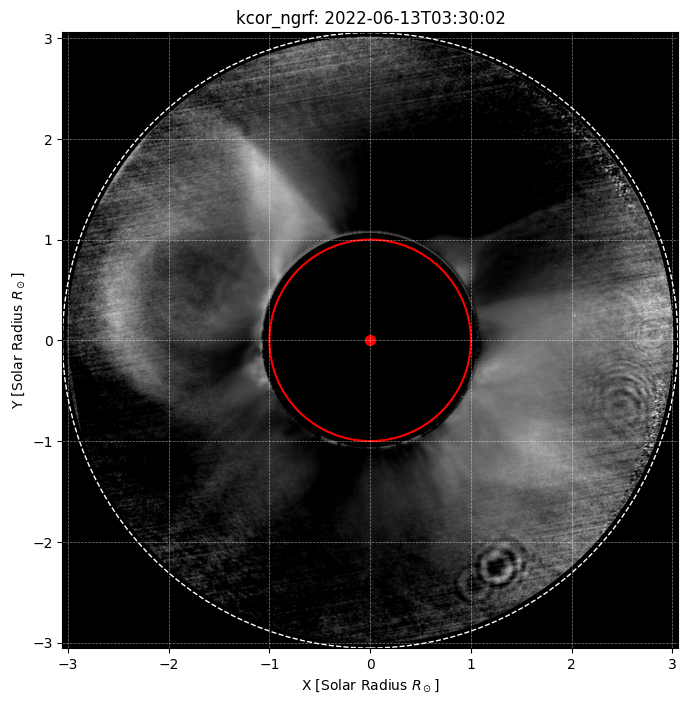

In [29]:

data, header = read_fits_file(fts_files[190])
fig, ax = plt.subplots(figsize=(8, 8))
draw_frame(data, header, ax)
plt.show()


### 動画として出力

In [62]:
if __name__ == '__main__':
    start_time = '2022-06-13 02:41'
    end_time = '2022-06-13 04:42'
    
    # 出力ファイル名を生成
    output_filename = f"mk4_movie_ngrf_{start_time.replace(':', '').replace(' ', '_')}_to_{end_time.replace(':', '').replace(' ', '_')}.mp4"
    output_path = os.path.join(output_folder, output_filename)
    
    
    # 修正した動画作成関数を呼び出し
    create_movie_from_fits_imageio(
        start_time_str=start_time,
        end_time_str=end_time,
        data_folder=data_folder,
        output_path=output_path,
        fps=10
    )

動画の作成を開始します...
対象期間: 2022-06-13 02:41:00.000 から 2022-06-13 04:42:00.000 まで
447 個のファイルからフレームを生成します。


フレーム生成中: 100%|██████████| 447/447 [10:46<00:00,  1.45s/it]



全447フレームをレンダリングしました。動画に変換します...

動画ファイル 'D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\output\mk4_movie_ngrf_2022-06-13_0241_to_2022-06-13_0442.mp4' が正常に作成されました。


## Test

In [ ]:
import numpy as np, matplotlib.pyplot as plt, io, gc, random, imageio.v2 as imageio
from astropy.time import Time
import astropy.units as u
import sunpy.map
from sunpy.map import Map, MapSequence


def load_kcor_nrgf_sequence(path_or_dir: str) -> MapSequence:
    """
    ・単一 FITS → そのまま MapSequence
    ・ディレクトリ   → 中の *.fits / *.fits.gz を読み込んで MapSequence
    """
    if os.path.isdir(path_or_dir):
        fits_list = sorted(
            glob.glob(os.path.join(path_or_dir, "*.fts"))
            + glob.glob(os.path.join(path_or_dir, "*.fts.gz"))
        )
        if not fits_list:
            raise FileNotFoundError("指定ディレクトリに *.fts が見つかりません。")
        return Map(fits_list, sequence=True, allow_errors=True)

    # 1 ファイルだけ渡された場合
    return Map(path_or_dir, sequence=True, allow_errors=True)


# --------- 軽量パーセンタイルを使う描画関数 ----------
def plot_difference_map(diff_map: sunpy.map.Map,
                        base_map_date: Time,
                        ax=None,
                        sample_pix: int = 100_000):   # 10万画素だけで近似
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1, projection=diff_map)

    data = diff_map.data
    if sample_pix and data.size > sample_pix:
        # ランダムに sample_pix 個取り出して 99.5 パーセンタイルを近似
        idx = np.random.choice(data.size, sample_pix, replace=False)
        vmax = np.percentile(np.abs(data.flat[idx]), 99.5)
    else:
        vmax = np.percentile(np.abs(data), 99.5)
    from astropy.visualization import ImageNormalize
    norm = ImageNormalize(vmin=-vmax, vmax=vmax)

    diff_map.plot(axes=ax, cmap="gray", norm=norm, annotate=False)
    diff_map.draw_limb(axes=ax, color="lime", linewidth=1)

    # …以下は以前と同じ（整数 Rsun 等高線など）
    rsun_arc = diff_map.meta.get("rsun_arc", diff_map.meta.get("RSUN_ARC"))
    if rsun_arc:
        x, y = np.meshgrid(*[np.arange(v.value) for v in diff_map.dimensions]) * u.pix
        coords = diff_map.pixel_to_world(x, y)
        rmap = np.hypot(coords.Tx, coords.Ty) / (rsun_arc * u.arcsec)
        ax.contour(rmap.value, levels=np.arange(2, 7), colors="lime",
                   linestyles="--", linewidths=1, alpha=0.5)

    ax.plot(0, 0, "+", color="yellow", markersize=10,
            transform=ax.get_transform("world"))
    ax.grid(True, color="white", linestyle=":", alpha=0.5)
    ax.set_xlabel("Solar-X (arcsec)");  ax.set_ylabel("Solar-Y (arcsec)")
    ax.set_title(
    "MLSO/Mk4-KCOR NGRF Running Diff\n"
        f"{base_map_date.strftime('%Y-%m-%d %H:%M:%S')} → "
        f"{diff_map.date.strftime('%H:%M:%S')}"
    )


# --------- メモリ効率版のムービー作成 ----------
def make_nrgf_difference_movie(
    path_or_dir: str,
    start_time_str: str,
    end_time_str: str,
    output_mp4: str,
    fps: int = 10,
):
    start_t = Time(start_time_str, scale="utc")   # ← ★
    end_t   = Time(end_time_str,   scale="utc")   # ← ★
    if start_t >= end_t:
        raise ValueError("start_time must be before end_time")

    print("NGRF データを読み込み中…")
    seq = load_kcor_nrgf_sequence(path_or_dir)
    seq = [m for m in seq if start_t <= m.date <= end_t]
    if len(seq) < 2:
        print("範囲内のフレームが 2 枚未満です。");  return
    print(f"  使用フレーム: {len(seq)}")

    FIGSIZE, DPI = (8, 8), 150
    print("MP4 にストリーミング書き出し中…")
    with imageio.get_writer(
            output_mp4,
            fps=fps,
            codec="libx264",          # ← 変更
            quality=8,
            macro_block_size=16,      # 1200x1200 は 16 の倍数なので問題なし
            ffmpeg_params=[
                "-pix_fmt", "yuv420p"  # ← 追加
            ]
    ) as writer:

        for i in range(1, len(seq)):
            base_map, next_map = seq[i-1], seq[i]
            diff_map = Map(next_map.data - base_map.data, next_map.meta)

            fig, ax = plt.subplots(
                figsize=FIGSIZE, dpi=DPI,
                subplot_kw={"projection": diff_map}   # ★ ここを追加 ★
            )
            plot_difference_map(diff_map, base_map.date, ax=ax, sample_pix=80_000)

            buf = io.BytesIO()
            fig.savefig(buf, format="png", dpi=DPI)
            buf.seek(0)
            writer.append_data(imageio.imread(buf)[..., :3])  # RGB
            buf.close();  plt.close(fig)

            # 小まめに GC を回すとメモリ回復が早い
            del diff_map, base_map, next_map
            gc.collect()

    print(f"完了: {output_mp4}")


if __name__ == "__main__":
    # ① 単一 FITS ファイルを直接指定しても…
    #nrgf_source = r"...\20220613.kcor_nrgf.fits"
    # ② ディレクトリを指定しても OK
    nrgf_source = (data_folder)

    output_dir = (
        r"D:\wsl\home\kinno-7010\Research\MK4_coronagraph"
        r"\MK4_coronagraph_KCOR\Subtraction_data\output"
    )
    os.makedirs(output_dir, exist_ok=True)

    start_time = "2022-06-13 03:10:00"
    end_time   = "2022-06-13 03:30:00"
    outpath = os.path.join(output_dir, "mk4_kcor_nrgf_diff_20220613.mp4")

    make_nrgf_difference_movie(nrgf_source, start_time, end_time, outpath, fps=10)

NGRF データを読み込み中…
  使用フレーム: 158
MP4 にストリーミング書き出し中…
完了: D:\wsl\home\kinno-7010\Research\MK4_coronagraph\MK4_coronagraph_KCOR\Subtraction_data\output\mk4_kcor_nrgf_diff_20220613.mp4
